# Module 3 — Attention is Message Passing: **Transformers & the Particle Transformer**
### TIFR ML School 2026 · *Sets, Graphs & Symmetry for High-Energy Physics*

Module 2 connected each particle to its $k$ nearest neighbours — a **hard** choice: every neighbour counts
equally, every non-neighbour not at all. **Attention** replaces that with a **soft, learned, all-to-all
graph**: every particle can talk to every other, with a weight computed on the fly. That is the Transformer,
and its HEP form is the **Particle Transformer (ParT)** — the current state of the art for jet tagging.

> **The one new ingredient: soft edges.** A GNN aggregates over fixed neighbours; attention aggregates over
> *all* particles with data-dependent weights $\alpha_{ij}=\mathrm{softmax}_j(q_i\!\cdot\!k_j)$. It is still
> message passing — the softmax weight $\alpha_{ij}$ is just a **soft adjacency matrix**, recomputed every
> layer. The aggregation (a weighted sum) is, once again, the Deep Sets pool from Module 1.

**What you will do, end-to-end:**
1. Implement **scaled dot-product** and **multi-head** attention from scratch (with masking) — and see in a
   short experiment *why* the $1/\sqrt{d_k}$ scaling is there.
2. **Prove in code** that attention *is* message passing on a soft complete graph, and that an attention layer
   is **permutation-equivariant** (sets need *no* positional encoding).
3. Build a Transformer encoder + **attention pooling** (Set Transformer's PMA / a class token).
4. Add ParT's **pairwise physics interaction bias** ($\ln\Delta,\ \ln k_T,\ \ln z,\ \ln m^2$) and check that
   it is **Lorentz-boost and rotation invariant** — a free preview of Module 4.
5. Learn the hard way why **masking is non-negotiable** (a padding bug you can watch happen).
6. **Train** a plain Transformer *and* a ParT for top-vs-QCD; compare AUC, ROC *and* **learning curves** to the
   PFN (0.973) and ParticleNet (0.992).
7. **Look inside:** plot an attention map, test whether attention **rediscovers locality**, and track
   **attention entropy** through depth.
8. Implement the Set Transformer's **ISAB** and **benchmark** its $O(N^2)\!\to\!O(Nm)$ speed-up.

**Dependencies:** `numpy torch matplotlib scikit-learn uproot awkward` (pure torch — no PyG this time).

## 1 · From hard k-NN edges to soft attention

Write a GNN layer and an attention layer side by side:

$$
\textbf{GNN: } \; h_i' = \phi\Big(h_i,\ \bigoplus_{j\in\mathcal N(i)} \psi(h_i,h_j)\Big)
\qquad\qquad
\textbf{Attention: } \; h_i' = \sum_{j} \alpha_{ij}\, v_j,\quad
\alpha_{ij} = \frac{\exp(q_i\!\cdot\!k_j/\sqrt d)}{\sum_{j'} \exp(q_i\!\cdot\!k_{j'}/\sqrt d)}
$$

The only differences: the neighbourhood is **all** particles, and the "edge weight" $\alpha_{ij}$ is **learned
and soft** (a probability) rather than a 0/1 k-NN membership. So a Transformer is a GNN on a **fully-connected
graph with a learned, normalized, per-layer adjacency**. Everything you know from Module 2 transfers.

Because the sum over $j$ is permutation-invariant, attention on a *set* needs **no positional encoding** — and
that is exactly what we want for particles, which have no canonical order.

## 2 · Scaled dot-product attention

Given queries $Q$, keys $K$, values $V$ (each a matrix with one row per particle):
$$ \mathrm{Attention}(Q,K,V) = \mathrm{softmax}\!\Big(\frac{QK^\top}{\sqrt{d_k}}\Big)\,V . $$
- $QK^\top$ scores how much particle $i$ (query) cares about particle $j$ (key);
- $\sqrt{d_k}$ keeps the scores from blowing up with dimension;
- softmax turns each row into attention weights $\alpha_{i\cdot}$ that sum to 1;
- multiplying by $V$ returns a weighted average of the value vectors.

We must **mask padded particles**: their key columns get $-\infty$ before the softmax so nobody attends to them.

In [1]:
%matplotlib inline
import math
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

torch.manual_seed(0); np.random.seed(0)
device = (torch.device("cuda") if torch.cuda.is_available()
          else torch.device("mps") if torch.backends.mps.is_available()
          else torch.device("cpu"))
print("torch", torch.__version__, "| device", device)

torch 2.12.0 | device mps


In [2]:
def scaled_dot_product_attention(q, k, v, key_mask=None, attn_bias=None):
    """q,k,v: (..., N, d). key_mask: (..., N) with 1=real, 0=pad. attn_bias: additive (..., N_q, N_k)."""
    d = q.shape[-1]
    scores = (q @ k.transpose(-2, -1)) / math.sqrt(d)         # (..., N_q, N_k)
    if attn_bias is not None:
        scores = scores + attn_bias
    if key_mask is not None:
        scores = scores.masked_fill(~key_mask.unsqueeze(-2).bool(), float("-inf"))
    attn = torch.nan_to_num(scores.softmax(dim=-1))            # rows over only-pad keys -> 0
    return attn @ v, attn

# tiny check: with one padded key, its attention weight must be exactly 0
q = torch.randn(1, 3, 8); k = torch.randn(1, 3, 8); v = torch.randn(1, 3, 8)
km = torch.tensor([[1., 1., 0.]])                              # 3rd "particle" is padding
_, a = scaled_dot_product_attention(q, k, v, key_mask=km)
print("attention to padded key (should be 0):", a[..., 2].abs().max().item())
print("each query row sums to 1:", a.sum(-1).flatten().tolist())

attention to padded key (should be 0): 0.0
each query row sums to 1: [1.0, 1.0, 1.0]


## 2a · Why the $1/\sqrt{d_k}$? (a 30-second experiment)

Before trusting the formula, let's *see* what the scaling buys. The dot product $q\!\cdot\!k$ of two random
$d_k$-vectors has **variance $\propto d_k$**, so raw scores grow like $\sqrt{d_k}$. Feed those large scores to a
softmax and it **saturates** — one key gets weight $\approx 1$, the rest $\approx 0$ — at which point the
softmax Jacobian, and therefore the gradient, **collapses**. Dividing by $\sqrt{d_k}$ keeps the scores $O(1)$,
the attention well-spread, and the layer trainable. We finish by cross-checking our kernel against PyTorch's
own fused `F.scaled_dot_product_attention`.

In [ ]:
import math, torch.nn.functional as F
torch.manual_seed(0)

# ---- (a) the variance problem: std(QK^T) ~ sqrt(d_k), and the softmax then collapses ----
N = 32                                                  # one query attends over N keys
print(f"{'d_k':>6} | {'std(QK^T)':>10} | {'max softmax weight':>18} | {'entropy/ln N':>14}")
for d in (4, 16, 64, 256, 1024):
    dots = (torch.randn(4000, d) * torch.randn(4000, d)).sum(-1)      # 4000 independent dot products
    s = torch.randn(N, d) @ torch.randn(d)                            # one UNSCALED score row
    p = s.softmax(0); H = -(p * (p + 1e-12).log()).sum() / math.log(N)
    print(f"{d:6d} | {dots.std():10.2f} | {p.max().item():18.3f} | {H.item():14.3f}")
print("-> std(QK^T) tracks sqrt(d_k) exactly; the unscaled softmax collapses onto ~1 key (entropy -> 0).")

# ---- (b) the consequence: an unscaled softmax gives uncontrolled gradients ----
print(f"\n{'d_k':>6} | {'||grad q|| UNSCALED':>20} | {'||grad q|| SCALED':>18}")
uns, sca = [], []
for d in (4, 64, 1024):
    k, v = torch.randn(N, d), torch.randn(N, 4)
    g = {}
    for tag, scale in (("u", 1.0), ("s", math.sqrt(d))):
        q = torch.randn(d, requires_grad=True)
        (((k @ q) / scale).softmax(0) @ v).sum().backward()
        g[tag] = q.grad.norm().item()
    uns.append(g["u"]); sca.append(g["s"]); print(f"{d:6d} | {g['u']:20.2e} | {g['s']:18.2e}")
print(f"-> scaled grad-norm is steady ~O(1) ({sca[0]:.2f}, {sca[1]:.2f}, {sca[2]:.2f}); unscaled is uncontrolled "
      f"({uns[0]:.2f} -> {uns[1]:.2f} -> {uns[2]:.4f}): it collapses by orders of magnitude as d_k saturates the softmax.")

# ---- (c) cross-check our kernel against PyTorch's fused SDPA (no mask/bias) ----
q, k, v = (torch.randn(3, 4, 20, 16) for _ in range(3))                # (B, heads, N, d_k)
ours, _ = scaled_dot_product_attention(q, k, v)
print(f"\nmax |ours - F.scaled_dot_product_attention| = {(ours - F.scaled_dot_product_attention(q,k,v)).abs().max():.1e}")

## 2b · Attention *is* message passing — the equality, in code

The thesis of this whole course is that every model is **constrained message passing**. Here is the proof for
attention. We compute $\mathrm{softmax}(QK^\top/\sqrt d)\,V$ **two ways**:
1. the Transformer one-liner (a couple of matmuls), and
2. an explicit, node-by-node loop that forms a message $\psi(q_i,k_j)=q_i\!\cdot\!k_j/\sqrt d$ on **every edge**,
   softmaxes the edge weights into $\alpha_{ij}$, and pools $\sum_j \alpha_{ij} v_j$ — exactly Module 2's
   message$\to$aggregate pattern, on a *complete* graph.

They are bit-for-bit identical. The soft adjacency $\alpha$ is just a **row-stochastic, learned, per-layer graph** —
Module 2's $k$-NN matrix, gone soft. We then confirm a whole attention **layer** is permutation-**equivariant**:
$f(Px)=Pf(x)$. (The pooling of §4 later turns that equivariance into the **invariance** a jet tagger needs.)

In [ ]:
import math
torch.manual_seed(0)
N, d = 6, 16
q, k, v = torch.randn(N, d), torch.randn(N, d), torch.randn(N, d)

# form A: the Transformer one-liner
out_matrix, alpha = scaled_dot_product_attention(q, k, v)           # softmax(QK^T / sqrt d) V

# form B: literal message passing, node by node (Module 2's message -> aggregate, on a complete graph)
out_mp = torch.empty_like(out_matrix)
for i in range(N):                                                  # loop over query nodes
    msg_i = torch.tensor([(q[i] @ k[j]) / math.sqrt(d) for j in range(N)])   # psi on every incoming edge
    a_i = msg_i.softmax(0)                                          # soft adjacency row (sums to 1)
    out_mp[i] = sum(a_i[j] * v[j] for j in range(N))               # permutation-invariant pool over neighbours
print(f"max |matrix form - explicit message-passing loop| = {(out_matrix - out_mp).abs().max():.1e}  -> SAME op")
print("each query's edge weights sum to 1 (row-stochastic 'soft graph'):", torch.allclose(alpha.sum(-1), torch.ones(N)))

# permutation EQUIvariance of a self-attention layer: with SHARED projections on each particle, f(Px) = P f(x)
torch.manual_seed(1)
Wq, Wk, Wv = (torch.randn(d, d) for _ in range(3))                # one projection set, applied to every particle
def self_attention(z):
    out, _ = scaled_dot_product_attention(z @ Wq, z @ Wk, z @ Wv)
    return out
xx = torch.randn(N, d); P = torch.randperm(N)                     # relabel the particles
print(f"max |P f(x) - f(P x)|                          = {(self_attention(xx)[P] - self_attention(xx[P])).abs().max():.1e}  -> equivariant")
print("(pooling, in section 4, collapses this equivariance into the permutation INvariance the jet tagger needs.)")

## 3 · Multi-head self-attention + encoder block

**Multi-head** attention runs $H$ attention "heads" in parallel on different learned projections, letting the
model attend to several kinds of relationship at once. We then build a standard **pre-LayerNorm encoder block**:
$$ x \leftarrow x + \mathrm{MHA}(\mathrm{LN}(x)), \qquad x \leftarrow x + \mathrm{FFN}(\mathrm{LN}(x)). $$
The block accepts an optional additive `attn_bias` — that is where ParT's physics will enter (§5).

In [3]:
class MultiHeadSelfAttention(nn.Module):
    def __init__(self, dim, heads):
        super().__init__()
        assert dim % heads == 0
        self.h, self.dk = heads, dim // heads
        self.qkv = nn.Linear(dim, 3 * dim)
        self.proj = nn.Linear(dim, dim)
    def forward(self, x, key_mask, attn_bias=None):
        B, N, _ = x.shape
        qkv = self.qkv(x).reshape(B, N, 3, self.h, self.dk).permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2]                       # each (B, h, N, dk)
        out, attn = scaled_dot_product_attention(
            q, k, v,
            key_mask=key_mask[:, None, :] if key_mask is not None else None,   # (B,1,N) -> broadcast over heads
            attn_bias=attn_bias)                                                # (B,h,N,N)
        out = out.transpose(1, 2).reshape(B, N, -1)
        return self.proj(out), attn

class EncoderBlock(nn.Module):
    def __init__(self, dim, heads, mlp_ratio=4, drop=0.1):
        super().__init__()
        self.ln1, self.ln2 = nn.LayerNorm(dim), nn.LayerNorm(dim)
        self.attn = MultiHeadSelfAttention(dim, heads)
        self.mlp = nn.Sequential(nn.Linear(dim, mlp_ratio * dim), nn.GELU(),
                                 nn.Dropout(drop), nn.Linear(mlp_ratio * dim, dim))
        self.drop = nn.Dropout(drop)
    def forward(self, x, key_mask, attn_bias=None):
        a, attn = self.attn(self.ln1(x), key_mask, attn_bias)
        x = x + self.drop(a)
        x = x + self.mlp(self.ln2(x))
        return x, attn

## 4 · Attention pooling (Set Transformer's PMA / a "class token")

To get one vector per jet we use **pooling by multi-head attention (PMA)**: a single learnable **class query**
attends over all particles and returns a weighted summary. This is permutation-invariant (it is a softmax-
weighted sum over the set) and is exactly the readout used by the Set Transformer and ParT (the "class
attention" block). It is a learnable, content-aware generalization of the mean-pool from Module 1.

In [ ]:
class AttentionPooling(nn.Module):
    """One learnable class token attends over the particles -> a single jet vector (Set Transformer PMA)."""
    def __init__(self, dim, heads):
        super().__init__()
        self.h, self.dk = heads, dim // heads
        self.cls = nn.Parameter(torch.randn(1, 1, dim) * 0.02)
        self.q, self.kv, self.proj = nn.Linear(dim, dim), nn.Linear(dim, 2 * dim), nn.Linear(dim, dim)
        self.last_attn = None                                                     # kept for interpretability (9c)
    def forward(self, x, key_mask):
        B, N, _ = x.shape
        q = self.q(self.cls.expand(B, 1, -1)).reshape(B, 1, self.h, self.dk).transpose(1, 2)  # (B,h,1,dk)
        kv = self.kv(x).reshape(B, N, 2, self.h, self.dk).permute(2, 0, 3, 1, 4)
        k, v = kv[0], kv[1]
        out, self.last_attn = scaled_dot_product_attention(q, k, v, key_mask=key_mask[:, None, :])  # attn:(B,h,1,N)
        return self.proj(out.transpose(1, 2).reshape(B, 1, -1)).squeeze(1)                      # (B,dim)

## 5 · The Particle Transformer (ParT) and its pairwise interaction bias

A plain Transformer treats particles as abstract tokens. **ParT** (Qu, Li, Qian, 2022) injects physics by
**adding a pairwise bias** $U_{ij}$ to the attention scores *before* the softmax:
$$ \mathrm{Attention} = \mathrm{softmax}\!\Big(\tfrac{QK^\top}{\sqrt{d_k}} + U\Big)V . $$
$U_{ij}$ is a small MLP of four interpretable Lorentz-motivated features of the particle **pair** $(i,j)$:
$$ \ln\Delta_{ij},\quad \ln k_{T,ij},\quad \ln z_{ij},\quad \ln m^2_{ij}, $$
with $\Delta=\sqrt{\Delta y^2+\Delta\phi^2}$, $k_T=\min(p_{T,i},p_{T,j})\,\Delta$,
$z=\min(p_{T,i},p_{T,j})/(p_{T,i}+p_{T,j})$, and $m^2$ the invariant mass$^2$ of the pair. These are exactly the
kinematics of the QCD splitting that produced the pair — a strong, physics-informed prior that is ParT's key
ingredient. We compute them from the particles' 4-momenta on the fly.

In [ ]:
def pairwise_features(p4, eps=1e-8):
    """p4: (B, N, 4) = (px, py, pz, E).  Returns U: (B, N, N, 4) = [lnDelta, ln kT, ln z, ln m^2], all finite."""
    px, py, pz, E = p4[..., 0], p4[..., 1], p4[..., 2], p4[..., 3]
    pt  = torch.sqrt(px**2 + py**2).clamp(min=1e-6)
    phi = torch.atan2(py, px)
    y   = 0.5 * torch.log(((E + pz).clamp(min=eps)) / ((E - pz).clamp(min=eps)))     # rapidity
    dy   = y[:, :, None] - y[:, None, :]
    dphi = phi[:, :, None] - phi[:, None, :]
    dphi = torch.atan2(torch.sin(dphi), torch.cos(dphi))                              # wrap to (-pi, pi], MPS-safe
    delta = torch.sqrt(dy**2 + dphi**2).clamp(min=1e-6)
    ptmin = torch.minimum(pt[:, :, None], pt[:, None, :])
    kt = (ptmin * delta).clamp(min=1e-6)
    z  = (ptmin / (pt[:, :, None] + pt[:, None, :] + eps)).clamp(min=1e-6, max=1.0)
    sE, spx = E[:, :, None] + E[:, None, :], px[:, :, None] + px[:, None, :]
    spy, spz = py[:, :, None] + py[:, None, :], pz[:, :, None] + pz[:, None, :]
    m2 = (sE**2 - spx**2 - spy**2 - spz**2).clamp(min=1e-6)
    return torch.stack([torch.log(delta), torch.log(kt), torch.log(z), torch.log(m2)], dim=-1)

class ParticleTransformer(nn.Module):
    def __init__(self, in_feat, n_classes, dim=64, depth=3, heads=4, drop=0.1, use_pair_bias=True):
        super().__init__()
        self.use_pair_bias, self.heads = use_pair_bias, heads
        self.embed = nn.Sequential(nn.Linear(in_feat, dim), nn.GELU(), nn.Linear(dim, dim))
        self.blocks = nn.ModuleList([EncoderBlock(dim, heads, drop=drop) for _ in range(depth)])
        self.pool = AttentionPooling(dim, heads)
        self.head = nn.Sequential(nn.LayerNorm(dim), nn.Linear(dim, n_classes))
        if use_pair_bias:
            self.pair_mlp = nn.Sequential(nn.Linear(4, 16), nn.GELU(), nn.Linear(16, heads))
        self.last_attn, self.attn_maps = None, []
    def forward(self, x, mask, p4=None):
        h = self.embed(x)
        bias = None
        if self.use_pair_bias and p4 is not None:
            bias = self.pair_mlp(pairwise_features(p4)).permute(0, 3, 1, 2)   # (B, heads, N, N)
        self.attn_maps = []
        for blk in self.blocks:
            h, self.last_attn = blk(h, mask, bias)
            self.attn_maps.append(self.last_attn)            # keep every block's attention map (used in 9b)
        return self.head(self.pool(h, mask))

## 5a · What the bias *sees*: interaction features and their Lorentz invariance

Let's make ParT's pairwise bias concrete. We build a synthetic **3-prong, top-like** jet out of massless
4-vectors, compute the four interaction features for *every* particle pair, and display them as heatmaps. Then
the physics payoff: because $\ln\Delta,\ \ln k_T,\ \ln z,\ \ln m^2$ are built from **Lorentz invariants**
(rapidity *differences*, transverse momenta, pair invariant mass), the bias does **not change** under a
**longitudinal boost** along the beam or an **azimuthal rotation** — and it is permutation-equivariant like
everything else. ParT inherits those symmetries *for free*, foreshadowing the equivariant networks of Module 4.

In [ ]:
# massless 4-vector from (pt, y, phi):  E = pt*cosh y,  pz = pt*sinh y
def p4_from(pt, y, phi):
    return np.stack([pt*np.cos(phi), pt*np.sin(phi), pt*np.sinh(y), pt*np.cosh(y)], -1)

rng = np.random.default_rng(0)
prongs = [(80., 0.05, 0.10), (60., 0.35, -0.25), (45., -0.20, 0.45)]    # 3 hard prongs (pt, y, phi)
rows = []
for pt0, y0, phi0 in prongs:
    rows.append((pt0, y0, phi0))
    for _ in range(4):                                                  # soft radiation around each prong
        rows.append((pt0*rng.uniform(0.03, 0.18), y0+rng.normal(0, 0.06), phi0+rng.normal(0, 0.06)))
rows.sort(key=lambda r: -r[0])                                          # order by pT (descending) for readability
pt, yy, phi = (np.array(c) for c in zip(*rows))
p4 = torch.tensor(p4_from(pt, yy, phi), dtype=torch.float64)[None]      # (1, N, 4); float64 for a crisp check
Npart = p4.shape[1]
U = pairwise_features(p4)[0]                                            # (N, N, 4)

names = [r"$\ln\Delta$", r"$\ln k_T$", r"$\ln z$", r"$\ln m^2$"]
fig, ax = plt.subplots(1, 4, figsize=(15, 3.6))
for a, ch in zip(ax, range(4)):
    im = a.imshow(U[..., ch], cmap="magma"); a.set_title(names[ch])
    a.set_xlabel("particle j"); a.set_ylabel("particle i"); fig.colorbar(im, ax=a, fraction=0.046)
fig.suptitle(f"ParT pairwise interaction features — one toy top jet ({Npart} particles, $p_T$-ordered)")
fig.tight_layout(); plt.show()

# the punchline: these features are invariant under a longitudinal boost and an azimuthal rotation
def boost_z(p, xi):                                                     # boost along beam by rapidity xi
    px, py, pz, E = p[...,0], p[...,1], p[...,2], p[...,3]
    return torch.stack([px, py, pz*np.cosh(xi)+E*np.sinh(xi), E*np.cosh(xi)+pz*np.sinh(xi)], -1)
def rot_z(p, th):                                                       # rotate about beam by angle th
    px, py, pz, E = p[...,0], p[...,1], p[...,2], p[...,3]
    return torch.stack([px*np.cos(th)-py*np.sin(th), px*np.sin(th)+py*np.cos(th), pz, E], -1)
print(f"max |U(jet) - U(boosted jet, xi=1.3)| = {(U - pairwise_features(boost_z(p4,1.3))[0]).abs().max():.1e}")
print(f"max |U(jet) - U(rotated jet, 0.7 rad)|= {(U - pairwise_features(rot_z(p4,0.7))[0]).abs().max():.1e}")
P = torch.randperm(Npart)
print(f"max |U[P][:,P] - U(P x)|  (perm-equiv)= {(U[P][:, P] - pairwise_features(p4[:, P])[0]).abs().max():.1e}")
print("-> the bias is a function of Lorentz invariants, so ParT is boost/rotation invariant for free (Module 4 preview).")

## 6 · Data: jets as (masked) sets again

Attention is naturally a dense, all-to-all computation, so we go back to Module 1's representation: pad each
jet to a fixed length and carry a 0/1 `mask`. We keep two tensors per jet:
- `x` — the 7 standardized particle features (input to the network), and
- `p4` — the **raw** 4-momenta $(p_x,p_y,p_z,E)$, needed to compute ParT's pairwise features.

In [6]:
import os, uproot, awkward as ak

CANDIDATE_PATHS = [
    "../data/JetClass_example_100k.root",
    "/Users/sanmay/Documents/ML_SCHOOLS/MLSCHOOL_2023_ICTS/Main_School/JetDataset/JetClass_example_100k.root",
    "./JetClass_example_100k.root",
]
root_path = next((p for p in CANDIDATE_PATHS if os.path.exists(p)), None)
if root_path is None:
    raise FileNotFoundError("Place JetClass_example_100k.root in ../data/  "
                            "(https://hqu.web.cern.ch/datasets/JetClass/example/)")

MAX_PART, N_PER_CLS = 128, 8000
tree = uproot.open(root_path)["tree"]
br = tree.arrays(["part_px","part_py","part_pz","part_energy","part_deta","part_dphi",
                  "label_QCD","label_Tbqq","label_Tbl"])
is_qcd = ak.to_numpy(br["label_QCD"]).astype(bool)
is_top = ak.to_numpy(br["label_Tbqq"]).astype(bool) | ak.to_numpy(br["label_Tbl"]).astype(bool)
sel = np.concatenate([np.where(is_qcd)[0][:N_PER_CLS], np.where(is_top)[0][:N_PER_CLS]])
labels = np.concatenate([np.zeros(N_PER_CLS), np.ones(N_PER_CLS)]).astype(np.int64)

px,py,pz,e = br["part_px"][sel], br["part_py"][sel], br["part_pz"][sel], br["part_energy"][sel]
deta,dphi  = br["part_deta"][sel], br["part_dphi"][sel]
pt = np.sqrt(px**2+py**2); dR = np.sqrt(deta**2+dphi**2)
sumpt, sume = ak.sum(pt,axis=1), ak.sum(e,axis=1)
feat_list = [deta, dphi, np.log(pt+1e-8), np.log(e+1e-8),
             np.log(pt/sumpt+1e-8), np.log(e/sume+1e-8), dR]
FEATURE_NAMES = ["deta","dphi","log_pt","log_e","log_pt_rel","log_e_rel","dR"]

def pad(f): return ak.to_numpy(ak.fill_none(ak.pad_none(f, MAX_PART, clip=True), 0.0))
X   = np.stack([pad(f) for f in feat_list], axis=-1).astype(np.float32)            # (Njet,N,7)
P4  = np.stack([pad(px), pad(py), pad(pz), pad(e)], axis=-1).astype(np.float32)    # (Njet,N,4) raw
nparts = np.minimum(ak.to_numpy(ak.num(pt, axis=1)), MAX_PART)
MASK = (np.arange(MAX_PART)[None,:] < nparts[:,None]).astype(np.float32)
print("X", X.shape, "| P4", P4.shape, "| MASK", MASK.shape)

X (16000, 128, 7) | P4 (16000, 128, 4) | MASK (16000, 128)


In [7]:
# standardize features (real particles only), shuffle, split 70/15/15, build loaders
realmask = MASK.astype(bool)
mean, std = X[realmask].mean(0), X[realmask].std(0) + 1e-6
X = (X - mean) / std

Xt, P4t, Mt, Yt = map(torch.from_numpy, (X, P4, MASK, labels))
g = torch.Generator().manual_seed(0)
perm = torch.randperm(len(Yt), generator=g)
Xt, P4t, Mt, Yt = Xt[perm], P4t[perm], Mt[perm], Yt[perm]
n = len(Yt); ntr, nva = int(0.70*n), int(0.15*n)
sl = {"train": slice(0,ntr), "val": slice(ntr,ntr+nva), "test": slice(ntr+nva,n)}

class JetSet(Dataset):
    def __init__(self, s): self.x, self.p4, self.m, self.y = Xt[s], P4t[s], Mt[s], Yt[s]
    def __len__(self): return len(self.y)
    def __getitem__(self, i): return self.x[i], self.p4[i], self.m[i], self.y[i]

loaders = {k: DataLoader(JetSet(s), batch_size=64, shuffle=(k=="train")) for k, s in sl.items()}
print({k: len(JetSet(s)) for k, s in sl.items()})

{'train': 11200, 'val': 2400, 'test': 2400}


## 6a · Masking is non-negotiable: a padding bug you can watch happen

Padding + masking is the **single most common silent bug** in set learning. Here is the failure mode, made
visible. We take one jet of $n$ real particles and embed it into **two different padded lengths**. *With* the
mask, the prediction is **identical** — the padding is invisible. *Without* it, real particles are allowed to
**attend to the zero-padded "ghost" slots**, so the logits **drift with how much you happened to pad** — a bug
that never crashes, it just quietly corrupts your results. The fix is the `-inf` masking already baked into
`scaled_dot_product_attention`. (We use a fresh, untrained model on a *synthetic* jet, so the lesson is
isolated from the data pipeline.)

In [ ]:
torch.manual_seed(0)
n, Fin = 12, 7                                                        # 7 = our number of particle features
xr  = torch.randn(n, Fin)                                              # one jet's real particle features
p4r = torch.randn(n, 4).abs() + 0.2; p4r[:, 3] = (p4r[:, :3]**2).sum(-1).sqrt() + 0.5   # valid-ish 4-vectors

def pack(Npad):                                                       # model signature is forward(x, mask, p4)
    x  = torch.zeros(1, Npad, Fin); x[0, :n]  = xr                    # pad the rest with zeros
    p4 = torch.zeros(1, Npad, 4);   p4[0, :n] = p4r
    m  = torch.zeros(1, Npad);      m[0, :n]  = 1.0                   # 1 = real, 0 = pad
    return x.to(device), m.to(device), p4.to(device)

demo = ParticleTransformer(Fin, 2, dim=32, depth=2, heads=4, use_pair_bias=True).to(device).eval()
with torch.no_grad():
    lo30, lo80 = demo(*pack(30)), demo(*pack(80))                     # RIGHT: mask supplied
    leak_masked = demo.last_attn[0].mean(0)[:n, n:].abs().max().item()
    (x30,_,p30), (x80,_,p80) = pack(30), pack(80)                     # WRONG: pretend every slot is real
    bug30 = demo(x30, torch.ones(1, 30, device=device), p30)
    bug80 = demo(x80, torch.ones(1, 80, device=device), p80)
    leak_unmasked = demo.last_attn[0].mean(0)[:n, n:].abs().max().item()

print(f"WITH mask    : |logits(pad=30) - logits(pad=80)| = {(lo30-lo80).abs().max():.2e}   <- padding is invisible")
print(f"WITHOUT mask : |logits(pad=30) - logits(pad=80)| = {(bug30-bug80).abs().max():.2e}   <- corrupted by padding")
print(f"max real->pad attention weight: masked = {leak_masked:.1e}   unmasked = {leak_unmasked:.3f}")
print("-> forget the mask and your prediction depends on how much you padded. Always mask.")

In [ ]:
from sklearn.metrics import roc_auc_score, roc_curve

@torch.no_grad()
def evaluate(model, loader):
    model.eval(); ys, ps, loss_sum, ntot = [], [], 0.0, 0
    for x, p4, m, y in loader:
        x, p4, m, y = x.to(device), p4.to(device), m.to(device), y.to(device)
        logits = model(x, m, p4)
        loss_sum += F.cross_entropy(logits, y, reduction="sum").item(); ntot += y.size(0)
        ys.append(y.cpu()); ps.append(F.softmax(logits, -1)[:, 1].cpu())
    yv, pv = torch.cat(ys).numpy(), torch.cat(ps).numpy()
    return {"loss": loss_sum/ntot, "acc": ((pv>0.5).astype(int)==yv).mean(),
            "auc": roc_auc_score(yv, pv), "y": yv, "p": pv}

def background_rejection(y, p, eff=0.5):
    fpr, tpr, _ = roc_curve(y, p)
    eps_b = np.interp(eff, tpr, fpr)
    eps_b = max(eps_b, 1.0 / max(int((y == 0).sum()), 1))   # floor at 1/N_bkg (finite-sample resolution)
    return 1.0 / eps_b

def train_model(model, loaders, epochs=12, lr=1e-3, wd=1e-4):
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    hist = {"train_loss": [], "val_loss": [], "val_acc": [], "val_auc": []}      # NEW: record curves (used in 7a)
    for ep in range(epochs):
        model.train(); run, nb = 0.0, 0
        for x, p4, m, y in loaders["train"]:
            x, p4, m, y = x.to(device), p4.to(device), m.to(device), y.to(device)
            loss = F.cross_entropy(model(x, m, p4), y)
            opt.zero_grad(); loss.backward(); opt.step()
            run += loss.item(); nb += 1
        sched.step()
        va = evaluate(model, loaders["val"])
        hist["train_loss"].append(run / max(nb, 1))
        for k in ("loss", "acc", "auc"): hist[f"val_{k}"].append(va[k])
        print(f"epoch {ep+1:2d}: train loss {run/max(nb,1):.3f}  val loss {va['loss']:.3f}  "
              f"acc {va['acc']:.3f}  AUC {va['auc']:.4f}")
    model.history = hist                                                         # stash curves on the model
    return model

## 7 · Train: plain Transformer vs Particle Transformer

We train two identical models that differ **only** in the pairwise bias, to isolate ParT's contribution.

In [9]:
print("=== Plain Transformer (no pairwise bias) ===")
plain = ParticleTransformer(len(FEATURE_NAMES), 2, dim=64, depth=3, heads=4, use_pair_bias=False).to(device)
train_model(plain, loaders, epochs=12)

=== Plain Transformer (no pairwise bias) ===


epoch  1: val loss 0.218  acc 0.918  AUC 0.9768


epoch  2: val loss 0.181  acc 0.935  AUC 0.9826


epoch  3: val loss 0.161  acc 0.934  AUC 0.9840


epoch  4: val loss 0.149  acc 0.942  AUC 0.9859


...

epoch  9: val loss 0.135  acc 0.948  AUC 0.9875


epoch 10: val loss 0.137  acc 0.947  AUC 0.9879


epoch 11: val loss 0.130  acc 0.949  AUC 0.9886


epoch 12: val loss 0.133  acc 0.950  AUC 0.9887


ParticleTransformer(
  (embed): Sequential(
    (0): Linear(in_features=7, out_features=64, bias=True)
    (1): GELU(approximate='none')
    (2): Linear(in_features=64, out_features=64, bias=True)
  )
  (blocks): ModuleList(
    (0-2): 3 x EncoderBlock(
      (ln1): LayerNorm((64,), eps=1e-05, elementwise_affine=True, bias=True)
      (ln2): LayerNorm((64,), eps=1e-05, elementwise_affine=True, bias=True)
      (attn): MultiHeadSelfAttention(
        (qkv): Linear(in_features=64, out_features=192, bias=True)
        (proj): Linear(in_features=64, out_features=64, bias=True)
      )
      (mlp): Sequential(
        (0): Linear(in_features=64, out_features=256, bias=True)
        (1): GELU(approximate='none')
        (2): Dropout(p=0.1, inplace=False)
        (3): Linear(in_features=256, out_features=64, bias=True)
      )
      (drop): Dropout(p=0.1, inplace=False)
    )
  )
  (pool): AttentionPooling(
    (q): Linear(in_features=64, out_features=64, bias=True)
    (kv): Linear(in_featur

In [10]:
print("=== Particle Transformer (with pairwise interaction bias) ===")
part = ParticleTransformer(len(FEATURE_NAMES), 2, dim=64, depth=3, heads=4, use_pair_bias=True).to(device)
train_model(part, loaders, epochs=12)

=== Particle Transformer (with pairwise interaction bias) ===


epoch  1: val loss 0.193  acc 0.933  AUC 0.9828


epoch  2: val loss 0.173  acc 0.940  AUC 0.9826


epoch  3: val loss 0.139  acc 0.947  AUC 0.9869


epoch  4: val loss 0.157  acc 0.943  AUC 0.9877


...

epoch  9: val loss 0.132  acc 0.950  AUC 0.9880


epoch 10: val loss 0.131  acc 0.954  AUC 0.9887


epoch 11: val loss 0.133  acc 0.954  AUC 0.9884


epoch 12: val loss 0.130  acc 0.953  AUC 0.9886


ParticleTransformer(
  (embed): Sequential(
    (0): Linear(in_features=7, out_features=64, bias=True)
    (1): GELU(approximate='none')
    (2): Linear(in_features=64, out_features=64, bias=True)
  )
  (blocks): ModuleList(
    (0-2): 3 x EncoderBlock(
      (ln1): LayerNorm((64,), eps=1e-05, elementwise_affine=True, bias=True)
      (ln2): LayerNorm((64,), eps=1e-05, elementwise_affine=True, bias=True)
      (attn): MultiHeadSelfAttention(
        (qkv): Linear(in_features=64, out_features=192, bias=True)
        (proj): Linear(in_features=64, out_features=64, bias=True)
      )
      (mlp): Sequential(
        (0): Linear(in_features=64, out_features=256, bias=True)
        (1): GELU(approximate='none')
        (2): Dropout(p=0.1, inplace=False)
        (3): Linear(in_features=256, out_features=64, bias=True)
      )
      (drop): Dropout(p=0.1, inplace=False)
    )
  )
  (pool): AttentionPooling(
    (q): Linear(in_features=64, out_features=64, bias=True)
    (kv): Linear(in_featur

Plain Transformer  test AUC = 0.9895   acc = 0.9513
Particle Transformer test AUC = 0.9908   acc = 0.9579
  Plain bkg rej 1/eps_B @ eps_S=0.3 / 0.5:   1210.0 /  1210.0
  ParT  bkg rej 1/eps_B @ eps_S=0.3 / 0.5:   1210.0 /   605.0
  (AUC is the headline comparator here; rejection is statistics-limited by the 1210 background test jets -- raise N_PER_CLS for finer numbers.)
  references on this task -> PFN (M1) AUC ~0.973 | ParticleNet (M2) AUC ~0.992


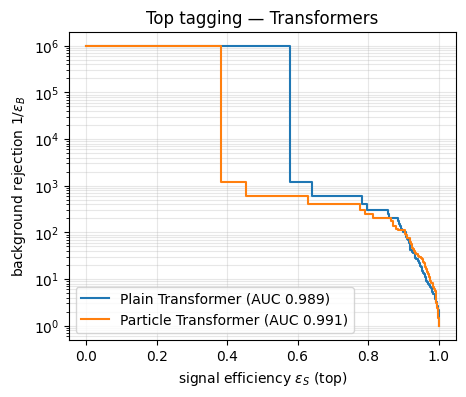

In [11]:
res_plain, res_part = evaluate(plain, loaders["test"]), evaluate(part, loaders["test"])
print(f"Plain Transformer  test AUC = {res_plain['auc']:.4f}   acc = {res_plain['acc']:.4f}")
print(f"Particle Transformer test AUC = {res_part['auc']:.4f}   acc = {res_part['acc']:.4f}")
for name, r in [("Plain", res_plain), ("ParT", res_part)]:
    rej = {e: background_rejection(r["y"], r["p"], e) for e in (0.3, 0.5)}
    print(f"  {name:5s} bkg rej 1/eps_B @ eps_S=0.3 / 0.5:  {rej[0.3]:7.1f} / {rej[0.5]:7.1f}")
print(f"  (AUC is the headline comparator here; rejection is statistics-limited by the "
      f"{int((res_plain['y']==0).sum())} background test jets -- raise N_PER_CLS for finer numbers.)")
print("  references on this task -> PFN (M1) AUC ~0.973 | ParticleNet (M2) AUC ~0.992")

plt.figure(figsize=(5, 4))
for r, lbl in [(res_plain, "Plain Transformer"), (res_part, "Particle Transformer")]:
    fpr, tpr, _ = roc_curve(r["y"], r["p"])
    plt.plot(tpr, 1.0/np.clip(fpr, 1e-6, 1), label=f"{lbl} (AUC {r['auc']:.3f})")
plt.yscale("log"); plt.xlabel("signal efficiency $\\epsilon_S$ (top)")
plt.ylabel("background rejection $1/\\epsilon_B$")
plt.grid(True, which="both", alpha=0.3); plt.legend(); plt.title("Top tagging — Transformers"); plt.show()

## 7a · Learning curves: does the physics prior also train *faster*?

`train_model` now stashes a `.history` of train/val loss and val AUC per epoch. Plotting the **trajectories**
(not just the final number) is the honest way to compare two models. ParT's pairwise bias is a strong
inductive prior, so it typically reaches a given AUC in **fewer epochs** and shows a smaller train$\to$val gap
(less overfitting) than the plain Transformer — the **inductive-bias $\leftrightarrow$ data trade-off** this
course revisits in every module.

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
for mdl, lbl in [(plain, "Plain Transformer"), (part, "Particle Transformer")]:
    ep = range(1, len(mdl.history["val_auc"]) + 1)
    line, = ax[0].plot(ep, mdl.history["val_loss"], "-o", label=f"{lbl} (val)")
    ax[0].plot(ep, mdl.history["train_loss"], "--", color=line.get_color(), alpha=.6, label=f"{lbl} (train)")
    ax[1].plot(ep, mdl.history["val_auc"], "-o", color=line.get_color(), label=lbl)
ax[0].set_xlabel("epoch"); ax[0].set_ylabel("cross-entropy"); ax[0].set_title("Loss (dashed=train, solid=val)")
ax[0].legend(fontsize=8); ax[0].grid(alpha=.3)
ax[1].set_xlabel("epoch"); ax[1].set_ylabel("validation AUC"); ax[1].set_title("Discrimination")
ax[1].legend(fontsize=8); ax[1].grid(alpha=.3)
fig.suptitle("Training curves: physics prior (ParT) vs none (plain)"); fig.tight_layout(); plt.show()

## 8 · No positional encoding: permutation invariance

A set model must give the same answer whatever the particle order. We shuffle a batch's particles (and their
4-momenta and mask) and confirm the logits are unchanged — the model never saw, and never needs, a position.

In [12]:
plain.eval(); part.eval()
x, p4, m, y = next(iter(loaders["test"]))
x, p4, m = x.to(device), p4.to(device), m.to(device)
pp = torch.randperm(x.shape[1])
with torch.no_grad():
    for name, model in [("Plain", plain), ("ParT", part)]:
        o1 = model(x, m, p4)
        o2 = model(x[:, pp], m[:, pp], p4[:, pp])
        print(f"{name:5s}: max |f(x) - f(shuffled x)| = {(o1-o2).abs().max().item():.2e}  (~0 => permutation invariant)")

Plain: max |f(x) - f(shuffled x)| = 4.77e-07  (~0 => permutation invariant)
ParT : max |f(x) - f(shuffled x)| = 6.56e-07  (~0 => permutation invariant)


## 9 · Looking inside: an attention map

We take one top jet and plot the last block's attention matrix (averaged over heads) among its real particles,
ordered by $p_T$. Bright rows/columns reveal which particles the network treats as important "hubs" — often
the hard, energetic prongs that define the jet's substructure.

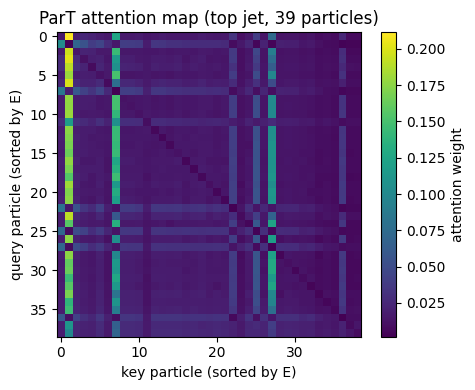

In [13]:
# one top jet from the test split
idx = [i for i in range(len(Yt)) if i >= sl["test"].start and Yt[i].item() == 1][0]
n = int(Mt[idx].sum().item())
xj, p4j, mj = Xt[idx:idx+1].to(device), P4t[idx:idx+1].to(device), Mt[idx:idx+1].to(device)
part.eval()
with torch.no_grad():
    part(xj, mj, p4j)
A = part.last_attn[0].mean(0).cpu().numpy()[:n, :n]     # (n,n) heads-averaged attention among real particles
order = np.argsort(-P4t[idx, :n, 3].numpy())            # sort by energy (E) for readability
A = A[order][:, order]
plt.figure(figsize=(5, 4))
plt.imshow(A, cmap="viridis"); plt.colorbar(label="attention weight")
plt.title(f"ParT attention map (top jet, {n} particles)")
plt.xlabel("key particle (sorted by E)"); plt.ylabel("query particle (sorted by E)")
plt.tight_layout(); plt.show()

## 9a · Does attention *rediscover* locality?

Module 2 **hard-wired** locality with a $k$-NN graph in $(\eta,\phi)$. Attention is free to wire anything to
anything — so does it *learn* to prefer nearby particles? For many test jets we head-average the last block's
attention and, for every real pair, divide its weight by the flat $1/n$ baseline (an **"enhancement over
uniform"**), then profile that against the pair separation $\Delta R_{ij}$. A trained ParT typically
**enhances small-$\Delta R$ pairs and suppresses far ones** — attention reconstructs, from data, the graph
Module 2 imposed by hand. (This is Exercise 5 of Module 2's theme, now worked for you.)

In [ ]:
@torch.no_grad()
def locality_profile(model, loader, nbatch=8, nbin=12):
    dR_all, enh_all = [], []
    for bi, (x, p4, m, y) in enumerate(loader):
        if bi >= nbatch: break
        x, p4, m = x.to(device), p4.to(device), m.to(device)
        model(x, m, p4)
        A = model.last_attn.mean(1)                                  # (B,N,N) head-averaged, last block
        n = m.sum(1, keepdim=True).clamp(min=1)
        enh = A * n[:, :, None]                                      # weight / (1/n) = enhancement over uniform
        dR = pairwise_features(p4)[..., 0].exp()                     # Delta R = exp(ln Delta)
        pair = (m[:, :, None] * m[:, None, :]).bool() & ~torch.eye(x.shape[1], dtype=torch.bool, device=x.device)
        dR_all.append(dR[pair].cpu().numpy()); enh_all.append(enh[pair].cpu().numpy())
    dR, enh = np.concatenate(dR_all), np.concatenate(enh_all)
    edges = np.linspace(0, np.percentile(dR, 99), nbin + 1); ctr = 0.5 * (edges[1:] + edges[:-1])
    b = np.clip(np.digitize(dR, edges) - 1, 0, nbin - 1)
    prof = np.array([enh[b == j].mean() if (b == j).any() else np.nan for j in range(nbin)])
    return ctr, prof

plt.figure(figsize=(5, 4))
for model, lbl in [(plain, "Plain"), (part, "ParT")]:
    c, pr = locality_profile(model, loaders["test"]); plt.plot(c, pr, "o-", label=lbl)
plt.axhline(1.0, ls="--", color="grey", label="flat (uniform 1/n)")
plt.xlabel(r"pair separation $\Delta R_{ij}$"); plt.ylabel("attention / uniform")
plt.title("Does attention rediscover locality?"); plt.legend(); plt.grid(alpha=.3)
plt.tight_layout(); plt.show()

## 9b · Do later layers *focus*? Attention entropy with depth

A complementary lens is the **entropy** of each attention row, normalized by $\ln n$ so that **1 = perfectly
uniform** and **0 = all weight on one particle**. Averaging over heads, query particles and jets at *each*
encoder block shows how sharply the network attends as information propagates through depth, and lets you
contrast the plain Transformer with ParT — whose physics bias steers *where*, and *how sharply*, attention
concentrates.

In [ ]:
@torch.no_grad()
def entropy_by_depth(model, loader, nbatch=8):
    acc, nb = None, 0
    for bi, (x, p4, m, y) in enumerate(loader):
        if bi >= nbatch: break
        x, p4, m = x.to(device), p4.to(device), m.to(device)
        model(x, m, p4)
        n = m.sum(1).clamp(min=2)
        per_block = []
        for A in model.attn_maps:                                    # each (B, heads, N, N)
            Abar = A.mean(1)                                         # average over heads -> (B,N,N)
            H = -(Abar * (Abar + 1e-12).log()).sum(-1)              # per-query entropy (pad keys have alpha=0)
            Hn = (H / n.log()[:, None])[m.bool()]                   # normalize by ln n; keep real queries only
            per_block.append(Hn.mean().item())
        acc = np.array(per_block) if acc is None else acc + np.array(per_block); nb += 1
    return acc / nb

plt.figure(figsize=(5, 4))
for model, lbl in [(plain, "Plain"), (part, "ParT")]:
    e = entropy_by_depth(model, loaders["test"])
    plt.plot(range(1, len(e) + 1), e, "o-", label=lbl)
plt.ylim(0, 1.05); plt.xlabel("encoder block"); plt.ylabel("normalized attention entropy")
plt.title("Attention entropy through depth (1=uniform, 0=peaked)"); plt.legend(); plt.grid(alpha=.3)
plt.tight_layout(); plt.show()

## 9c · Attention as attribution: per-particle importance on an event display

Sections 9–9b *looked at* attention; now we *use* it. We turn the attention scores into a **per-particle
importance** and draw it on the jet's $\eta$–$\phi$ image — the way an experimentalist reads an event display.

**Which score?** For this architecture there is one especially principled choice: the **class-attention
readout** itself. Recall (§4) that the jet vector is built by a single learnable *class query* attending over
the particles,
$$ z_{\text{jet}} \;=\; \sum_i \alpha_i\, v(h_i), \qquad \alpha_i \ge 0,\quad \textstyle\sum_i \alpha_i = 1 , $$
with $\alpha=\mathrm{softmax}$ of the class query against each particle (head-averaged here). Because the
$\alpha_i$ are non-negative and sum to one, **$\alpha_i$ is exactly the fraction of the jet representation that
particle $i$ contributes** — a built-in, normalized importance that needs no extra machinery. (It is the same
"class attention" used as the readout in ParT and in CaiT.) We exposed these weights by storing
`self.last_attn` inside `AttentionPooling`.

**How to read the plots.** Marker **area $\propto p_T$**, marker **colour $\propto$ importance**. A top jet
($t\!\to\!bW\!\to\!bqq$) should light up **two–three compact, hard centres** — the decay prongs — while a QCD
jet typically pours its attention onto a **single** hard core. The printed table lists each shown jet's five
most-attended particles with their kinematics, so you can check the bright markers really are the hard prongs.

> **Caveat (resolved in 9d):** these weights attribute importance to the **last-layer** particle tokens, which
> have *already* mixed information across the jet through three encoder blocks. To trace importance back to the
> **input** particles we need *attention rollout*.

In [ ]:
part.eval()

def eta_phi_pt(p4, mask):
    """Raw 4-vectors -> (Delta y, Delta phi, pT) in the pT-weighted jet frame, for event displays."""
    px, py, pz, E = p4.unbind(-1)
    pt  = (px**2 + py**2).sqrt().clamp(min=1e-6)
    phi = torch.atan2(py, px)
    y   = 0.5 * torch.log(((E + pz).clamp(min=1e-8)) / ((E - pz).clamp(min=1e-8)))
    w   = pt * mask                                                              # pT-weight, real particles only
    y0   = (w * y).sum(-1) / w.sum(-1).clamp(min=1e-6)
    phi0 = torch.atan2((w * phi.sin()).sum(-1), (w * phi.cos()).sum(-1))         # circular mean of phi
    dphi = torch.atan2((phi - phi0[..., None]).sin(), (phi - phi0[..., None]).cos())
    return (y - y0[..., None]), dphi, pt

@torch.no_grad()
def class_importance(model, x, p4, m):
    """Per-particle importance = head-averaged class-attention of the PMA readout, masked & normalized to sum 1."""
    model(x, m, p4)
    imp = (model.pool.last_attn.mean(1).squeeze(1) * m)                          # (B,N)
    return imp / imp.sum(-1, keepdim=True).clamp(min=1e-9)

# one top jet and one QCD jet from the test split
top_idx = next(i for i in range(sl["test"].start, len(Yt)) if Yt[i].item() == 1)
qcd_idx = next(i for i in range(sl["test"].start, len(Yt)) if Yt[i].item() == 0)
sel = torch.tensor([top_idx, qcd_idx])
x, p4, m = Xt[sel].to(device), P4t[sel].to(device), Mt[sel].to(device)
imp = class_importance(part, x, p4, m).cpu()
dy, dphi, pt = eta_phi_pt(p4.cpu(), m.cpu())

fig, axes = plt.subplots(1, 2, figsize=(11, 4.6), sharex=True, sharey=True)
for ax, j, title in zip(axes, range(2), ["Top jet", "QCD jet"]):
    n = int(m[j].sum().item()); ip = imp[j, :n].numpy(); ptj = pt[j, :n].numpy()
    sc = ax.scatter(dphi[j, :n], dy[j, :n], s=15 + 300 * ptj / ptj.max(),
                    c=ip, cmap="plasma", edgecolor="k", linewidth=0.3)
    ax.set_title(f"{title}  ({n} particles)"); ax.set_xlabel(r"$\Delta\phi$")
    fig.colorbar(sc, ax=ax, label="class-attention importance")
axes[0].set_ylabel(r"$\Delta y$")
fig.suptitle(r"Per-particle importance on the $\eta$–$\phi$ plane  (marker area $\propto p_T$)")
fig.tight_layout(); plt.show()

j = 0; n = int(m[j].sum().item()); ip = imp[j, :n].numpy()                       # top jet table
print("Top jet — five most-attended particles:")
print(f"{'rank':>4} {'importance':>11} {'pT [GeV]':>9} {'dy':>7} {'dphi':>7}")
for r, p in enumerate(np.argsort(-ip)[:5]):
    print(f"{r+1:>4} {ip[p]:>11.3f} {pt[j,p].item():>9.1f} {dy[j,p].item():>7.2f} {dphi[j,p].item():>7.2f}")

## 9d · Attention rollout: tracing influence back through every layer

A single attention matrix over-promises. Every encoder block **mixes** particles (that is its job), so by the
final block "the token for particle $i$" is already a blend of many input particles — and the class-attention
of §9c attributes importance to those *blended* tokens, not to the original particles. **Attention rollout**
(Abnar & Zuidema, ACL 2020) corrects for this by composing the per-layer attention.

**Recipe.** Head-average block $\ell$'s attention to $\bar A_\ell$ (rows already sum to 1). A residual
connection lets every token carry its own value forward, so the *effective* mixing of layer $\ell$ is
$$ \tilde A_\ell \;=\; \tfrac12\,\bar A_\ell + \tfrac12\, I \quad(\text{row-renormalised}), \qquad
   R \;=\; \tilde A_L\,\tilde A_{L-1}\cdots\tilde A_1 , $$
where $R_{ij}$ is the influence of input particle $j$ on the layer-$L$ token $i$. Finally **fold in the
readout**: the classifier reads token $i$ with class-weight $\bar p_i$ (§9c), so the importance of the *input*
particle $j$ is $\;\mathrm{imp}_j=(\bar p\,R)_j$.

**Read the assumptions honestly.** Rollout models the Transformer as pure **linear token-mixing**: it ignores
the *values*, the MLP nonlinearities, LayerNorm, and the input-dependence of the softmax; the $\tfrac12/\tfrac12$
residual split is a heuristic. It is an *approximation*, not a causal attribution — but a cheap, standard, and
usually informative one. (For a gradient-aware upgrade, see Chefer et al., CVPR 2021 — Exercise 8.) Below we put
the last-layer-only importance next to the rollout importance for the **same** top jet, and quantify the gap.

In [ ]:
@torch.no_grad()
def rollout_importance(model, x, p4, m):
    model(x, m, p4)
    B, N = m.shape
    I = torch.eye(N, device=x.device)[None]
    R = I.repeat(B, 1, 1)
    for A in model.attn_maps:                                                   # each (B,h,N,N)
        Ah = 0.5 * A.mean(1) + 0.5 * I                                          # head-avg + residual identity
        Ah = Ah / Ah.sum(-1, keepdim=True).clamp(min=1e-9)                      # renormalize rows
        R = Ah @ R                                                              # compose layers
    p = model.pool.last_attn.mean(1)                                           # (B,1,N) class attention
    imp = (p @ R).squeeze(1) * m                                              # fold readout through the rollout
    return imp / imp.sum(-1, keepdim=True).clamp(min=1e-9)

sel = torch.tensor([top_idx])                                                  # the same top jet as 9c
x, p4, m = Xt[sel].to(device), P4t[sel].to(device), Mt[sel].to(device)
imp_last = class_importance(part, x, p4, m)[0].cpu().numpy()
imp_roll = rollout_importance(part, x, p4, m)[0].cpu().numpy()
dy, dphi, pt = eta_phi_pt(p4.cpu(), m.cpu()); n = int(m[0].sum().item())

fig, axes = plt.subplots(1, 2, figsize=(11, 4.6), sharex=True, sharey=True)
for ax, ip, title in zip(axes, [imp_last, imp_roll],
                         ["class-attention (last layer only)", "attention rollout (all layers)"]):
    ipv = ip[:n]; ptj = pt[0, :n].numpy()
    sc = ax.scatter(dphi[0, :n], dy[0, :n], s=15 + 300 * ptj / ptj.max(),
                    c=ipv, cmap="plasma", edgecolor="k", linewidth=0.3)
    ax.set_title(title); ax.set_xlabel(r"$\Delta\phi$"); fig.colorbar(sc, ax=ax, label="importance")
axes[0].set_ylabel(r"$\Delta y$"); fig.suptitle("Same top jet, two attributions"); fig.tight_layout(); plt.show()

print(f"L1 |rollout - last-layer| over particles = {np.abs(imp_roll[:n] - imp_last[:n]).sum():.3f}  (0 = identical)")
print(f"most-important particle:  last-layer #{imp_last[:n].argmax()}   |   rollout #{imp_roll[:n].argmax()}")

## 9e · What does the model key on? A population view — and is attention *faithful*?

One jet is an anecdote. To make a defensible statement we **aggregate over many jets**. Below we profile the
mean class-attention importance against (i) a particle's **$p_T$-rank** inside its jet (0 = hardest) and
(ii) its angular distance **$\Delta R$ from the jet axis**, separately for **top** and **QCD** jets. The
pattern to expect: the network concentrates importance on the **few hardest, most central** particles — the
prongs — with top jets spreading attention over *more* centres than single-core QCD jets.

**A necessary health-warning — attention is not automatically an explanation.** Two influential papers frame
the debate: *"Attention is not Explanation"* (Jain & Wallace, NAACL 2019) shows attention weights can be
altered without changing the prediction, while *"Attention is not not Explanation"* (Wiegreffe & Pinter, EMNLP
2019) shows they still carry real, if partial, signal. The safe practice is to **corroborate attention with an
independent attribution**. We use the cheapest one — **input-gradient saliency**
$\,s_i=\lVert \partial(\text{top logit})/\partial x_i\rVert_1\,$ — and report the **top-$k$ overlap** between
the particles attention ranks highest and those the gradient ranks highest. High overlap (well above the
$\sim k/\langle n\rangle$ random baseline) means the two lenses agree and the attention story is trustworthy
*here*; low overlap means treat the pretty pictures with caution. A more faithful, attention-native method is
gradient-weighted rollout (Exercise 8).

In [ ]:
@torch.no_grad()
def importance_profiles(model, cls, nmax=400, kbins=8, rbins=8):
    sel = (Yt == cls).nonzero().squeeze(1); sel = sel[sel >= sl["test"].start][:nmax]
    x, p4, m = Xt[sel].to(device), P4t[sel].to(device), Mt[sel].to(device)
    imp = class_importance(model, x, p4, m)
    dy, dphi, pt = eta_phi_pt(p4, m); dR = (dy**2 + dphi**2).sqrt()
    rank = (-pt + (1 - m) * 1e9).argsort(-1).argsort(-1)                         # 0 = hardest; pads last
    by_rank = np.array([imp[(rank == k) & m.bool()].mean().item()
                        if ((rank == k) & m.bool()).any() else np.nan for k in range(kbins)])
    edges = np.linspace(0, 0.8, rbins + 1); ctr = 0.5 * (edges[1:] + edges[:-1])
    dRf, impf = dR[m.bool()].cpu().numpy(), imp[m.bool()].cpu().numpy()
    b = np.clip(np.digitize(dRf, edges) - 1, 0, rbins - 1)
    by_dR = np.array([impf[b == i].mean() if (b == i).any() else np.nan for i in range(rbins)])
    return by_rank, ctr, by_dR

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
for cls, lbl, col in [(1, "Top", "C3"), (0, "QCD", "C0")]:
    by_rank, ctr, by_dR = importance_profiles(part, cls)
    ax[0].plot(range(len(by_rank)), by_rank, "o-", color=col, label=lbl)
    ax[1].plot(ctr, by_dR, "o-", color=col, label=lbl)
ax[0].set_xlabel(r"particle $p_T$-rank (0 = hardest)"); ax[0].set_ylabel("mean importance")
ax[0].set_title("Attention favours the hard particles"); ax[0].legend(); ax[0].grid(alpha=.3)
ax[1].set_xlabel(r"$\Delta R$ from jet axis"); ax[1].set_ylabel("mean importance")
ax[1].set_title("…and the central ones"); ax[1].legend(); ax[1].grid(alpha=.3)
fig.tight_layout(); plt.show()

# faithfulness cross-check: attention importance vs input-gradient saliency
def grad_saliency(model, x, p4, m):
    x = x.clone().requires_grad_(True)
    g, = torch.autograd.grad(model(x, m, p4)[:, 1].sum(), x)                     # d(top logit)/d(input features)
    return g.abs().sum(-1) * m
sel = (Yt == 1).nonzero().squeeze(1); sel = sel[sel >= sl["test"].start][:256]
x, p4, m = Xt[sel].to(device), P4t[sel].to(device), Mt[sel].to(device)
att, sal = class_importance(part, x, p4, m), grad_saliency(part, x, p4, m)
def overlap_at_k(a, b, m, k):
    big = (1 - m) * -1e9; ta, tb = (a + big).topk(k, -1).indices, (b + big).topk(k, -1).indices
    return float(np.mean([len(set(ta[i].tolist()) & set(tb[i].tolist())) / k for i in range(a.shape[0])]))
for k in (1, 3, 5):
    print(f"attention vs gradient-saliency:  top-{k} overlap = {overlap_at_k(att, sal, m, k):.2f}")
print("(1.0 = identical top-k; compare to the small random baseline ~k/<n_particles>. Agreement => trust the map.)")

## 10 · Where this sits: the Set Transformer

The pieces you built are the **Set Transformer** (Lee et al., 2019) vocabulary:
- **SAB** (Set Attention Block) = our `EncoderBlock` (self-attention over the set).
- **PMA** (Pooling by Multihead Attention) = our `AttentionPooling` (a learnable seed/class query).
- **ISAB** (Induced SAB) = the $O(N)$ trick: attend through $m\ll N$ learnable *inducing points* instead of
  all-to-all, cutting cost from $O(N^2)$ to $O(Nm)$ — useful for very high-multiplicity events (left as an
  exercise). ParT is essentially a domain-specialized Set Transformer with the physics pairwise bias.

## 10a · ISAB in code: $O(N^2)\to O(Nm)$, benchmarked

All-to-all attention costs $O(N^2)$ — painful for high-multiplicity events (pileup, full-detector point
clouds). The Set Transformer's fix is to route everything through $m\ll N$ learnable **inducing points**: the
set first *writes* into them, `H = MAB(I, X)`, then *reads back*, `Y = MAB(X, H)`. Two cross-attentions, each
$O(Nm)$, replace one $O(N^2)$ self-attention. Below we build the **MAB / SAB / ISAB** vocabulary on top of our
own `scaled_dot_product_attention`, confirm ISAB is still permutation-equivariant, and **benchmark** the
wall-clock scaling — SAB blows up quadratically while ISAB stays roughly linear.

In [ ]:
import time

class MAB(nn.Module):
    """Multihead Attention Block: queries A attend over keys/values B (pre-LN) + FFN. The Set Transformer atom."""
    def __init__(self, dim, heads, mlp_ratio=2):
        super().__init__()
        self.h, self.dk = heads, dim // heads
        self.lnA, self.lnB, self.ln2 = nn.LayerNorm(dim), nn.LayerNorm(dim), nn.LayerNorm(dim)
        self.q, self.kv, self.proj = nn.Linear(dim, dim), nn.Linear(dim, 2*dim), nn.Linear(dim, dim)
        self.ff = nn.Sequential(nn.Linear(dim, mlp_ratio*dim), nn.GELU(), nn.Linear(mlp_ratio*dim, dim))
    def forward(self, A, B, key_mask=None):
        Aw, Bw = self.lnA(A), self.lnB(B)
        q = self.q(Aw).reshape(*Aw.shape[:2], self.h, self.dk).transpose(1, 2)
        kv = self.kv(Bw).reshape(*Bw.shape[:2], 2, self.h, self.dk).permute(2, 0, 3, 1, 4)
        out, _ = scaled_dot_product_attention(q, kv[0], kv[1],
                    key_mask=key_mask[:, None, :] if key_mask is not None else None)
        x = A + self.proj(out.transpose(1, 2).reshape(*Aw.shape[:2], -1))
        return x + self.ff(self.ln2(x))

class SAB(nn.Module):                                       # full self-attention: O(N^2)  (= our EncoderBlock)
    def __init__(self, dim, heads): super().__init__(); self.mab = MAB(dim, heads)
    def forward(self, X, key_mask=None): return self.mab(X, X, key_mask)

class ISAB(nn.Module):                                      # induced: O(N*m) via m learnable inducing points
    def __init__(self, dim, heads, m=16):
        super().__init__()
        self.I = nn.Parameter(torch.randn(1, m, dim) * 0.02)
        self.mab1, self.mab2 = MAB(dim, heads), MAB(dim, heads)
    def forward(self, X, key_mask=None):
        H = self.mab1(self.I.expand(X.shape[0], -1, -1), X, key_mask)   # set -> inducing summary: (B,m,d)
        return self.mab2(X, H)                                          # set reads back: (B,N,d)

torch.manual_seed(0)
dim, heads, m, B = 64, 4, 16, 8
sab, isab = SAB(dim, heads).eval(), ISAB(dim, heads, m).eval()

# still permutation-equivariant
X = torch.randn(1, 40, dim); P = torch.randperm(40)
with torch.no_grad():
    print(f"ISAB permutation-equivariance |Y[P]-Y(P x)| = {(isab(X)[:, P] - isab(X[:, P])).abs().max():.1e}")

# timing: SAB (quadratic) vs ISAB (linear) as the set grows  (timed on CPU for a clean comparison)
def bench(mod, N, reps=6):
    Xb = torch.randn(B, N, dim)
    with torch.no_grad():
        mod(Xb)                                             # warm up
        t = time.perf_counter()
        for _ in range(reps): mod(Xb)
    return (time.perf_counter() - t) / reps * 1e3           # ms / forward

Ns = [64, 128, 256, 512, 1024]
t_sab  = [bench(sab,  N) for N in Ns]
t_isab = [bench(isab, N) for N in Ns]
print(f"\n{'N':>6} | {'SAB ms':>8} | {'ISAB ms':>8} | {'speedup':>7}")
for N, a, b in zip(Ns, t_sab, t_isab): print(f"{N:6d} | {a:8.2f} | {b:8.2f} | {a/b:6.2f}x")
print(f"SAB  time grew {t_sab[-1]/t_sab[0]:.0f}x for a 16x larger set (~256x if purely quadratic);")
print(f"ISAB time grew {t_isab[-1]/t_isab[0]:.0f}x -- linear scaling, the win for huge events.")

plt.figure(figsize=(5, 4))
plt.loglog(Ns, t_sab, "o-", label=r"SAB  $O(N^2)$")
plt.loglog(Ns, t_isab, "s-", label=fr"ISAB $O(Nm)$, m={m}")
plt.loglog(Ns, [t_sab[0]*(N/Ns[0])**2 for N in Ns], "k--", alpha=.4, label=r"$N^2$ ref")
plt.loglog(Ns, [t_isab[0]*(N/Ns[0]) for N in Ns], "k:", alpha=.6, label=r"$N$ ref")
plt.xlabel("set size N"); plt.ylabel("ms / forward"); plt.legend(); plt.grid(True, which="both", alpha=.3)
plt.title("Induced attention scales linearly"); plt.tight_layout(); plt.show()

## 11 · Exercises

1. **Ablate the bias features.** Retrain ParT with the pairwise bias restricted to only $\ln\Delta$, or only
   $\ln m^2$ (slice `pairwise_features` and shrink `pair_mlp`'s input). Which of the four features carries most
   of ParT's advantage? (§5a *visualized* the features; here you measure their *value*.)
2. **Depth / heads / width.** Sweep `depth`, `heads`, `dim`. Where are the diminishing returns for jets, and
   how does §7a's training curve change?
3. **Class attention vs mean pool.** Replace `AttentionPooling` with the masked mean-pool from Module 1. How
   much does learnable pooling actually help?
4. **ISAB accuracy trade-off.** §10a benchmarked ISAB's *speed*. Now swap the encoder's full-attention blocks
   for `ISAB` ($m=16, 32$), retrain, and measure the *AUC* you trade for the linear scaling.
5. **Attention $\to$ graph.** §9a showed attention enhances small-$\Delta R$ pairs. Now **threshold** a trained
   attention map at its top-$k$ entries per row and compare the induced graph, jet-by-jet, to ParticleNet's
   k-NN graph (Module 2). Does attention rediscover the *same* neighbours?
6. **Three-way race.** Put PFN (M1), ParticleNet (M2) and ParT (M3) on one ROC / rejection plot for the same
   test jets.
7. **Boost augmentation.** The bias is longitudinal-boost invariant (§5a) but the *input* features
   (`log_pt`, `log_e`, …) are **not**. Add random longitudinal boosts as data augmentation: does it help, and
   does ParT — already partly boost-aware through its bias — benefit *less* than the plain Transformer?
8. **Faithful attribution.** §9e showed attention and gradient saliency only *partly* agree. Implement
   **gradient-weighted attention rollout** (Chefer et al., 2021): before composing, weight each layer's
   attention by $\mathbb{E}_h\big[(\partial y_c/\partial A_\ell)\odot A_\ell\big]_+$. Does the importance
   map shift onto the particles the gradient says matter?

## 12 · Recap, and the bridge to Module 4

- **Attention** is message passing on a **fully-connected graph with a soft, learned, per-layer adjacency**
  $\alpha_{ij}$; the aggregation is still the Deep Sets weighted sum.
- We built scaled dot-product + multi-head attention, an encoder, and **attention pooling** (Set Transformer
  PMA), all **permutation-invariant** — sets need no positional encoding.
- **ParT** adds a **physics pairwise bias** ($\ln\Delta,\ln k_T,\ln z,\ln m^2$) to the attention logits, the
  ingredient that makes transformers the state of the art for jet tagging.

**What's still missing?** Every model so far is built in only on **permutation** symmetry. But physics has
*more* symmetry: rotations, translations, and the full **Lorentz** group. A top jet is a top jet in any boosted
frame. In **Module 4** we bake those symmetries directly into the network — **equivariant graph networks**
(EGNN, LorentzNet, PELICAN) — and see how much data efficiency a physical inductive bias buys.